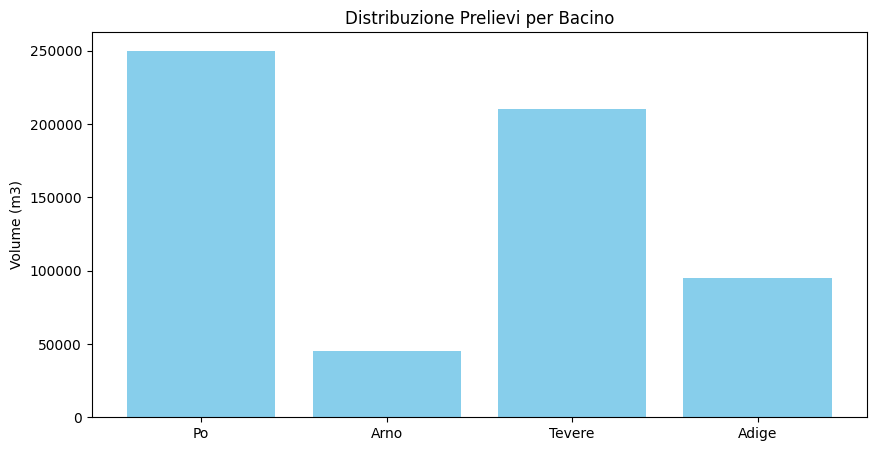

Database 'prelievi_idrici' pronto e primo grafico generato!


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

# Creazione dataset per il Progetto B
data_prelievi = {
    'nome_bacino': ['Po', 'Arno', 'Tevere', 'Po', 'Tevere', 'Arno', 'Adige', 'Po', 'Adige', 'Tevere'],
    'tipo_prelievo': ['Irriguo', 'Civile', 'Industriale', 'Civile', 'Irriguo', 'Industriale', 'Irriguo', 'Industriale', 'Civile', 'Civile'],
    'codice_sensore': ['S01', 'S02', 'S03', 'S04', 'S05', 'S06', 'S07', 'S08', 'S09', 'S10'],
    'volume_m3': [150000, 45000, 89000, 120000, 210000, 32000, 95000, 250000, 55000, 78000]
}

df_prelievi = pd.DataFrame(data_prelievi)
engine = create_engine('sqlite://')
df_prelievi.to_sql('prelievi_idrici', engine, index=False)

# --- IL TUO PRIMO GRAFICO GEOLOGICO ---
plt.figure(figsize=(10, 5))
plt.bar(df_prelievi['nome_bacino'], df_prelievi['volume_m3'], color='skyblue')
plt.title('Distribuzione Prelievi per Bacino')
plt.ylabel('Volume (m3)')
plt.show()

print("Database 'prelievi_idrici' pronto e primo grafico generato!")

In [9]:
# Soluzione corretta Punto 1
query_1 = "SELECT COUNT(DISTINCT nome_bacino) AS totale_bacini FROM prelievi_idrici;"
print(pd.read_sql_query(query_1, engine))

# Soluzione corretta Punto 2
query_2 = """
SELECT nome_bacino, SUM(volume_m3) AS volume_totale
FROM prelievi_idrici
GROUP BY nome_bacino
ORDER BY volume_totale DESC;
"""
print(pd.read_sql_query(query_2, engine))

# Soluzione corretta Punto 3
query_3 = """
SELECT nome_bacino, tipo_prelievo, MIN(volume_m3) AS volume_minimo
FROM prelievi_idrici
GROUP BY nome_bacino, tipo_prelievo
ORDER BY nome_bacino, tipo_prelievo;
"""
print(pd.read_sql_query(query_3, engine))

   totale_bacini
0              4
  nome_bacino  volume_totale
0          Po         520000
1      Tevere         377000
2       Adige         150000
3        Arno          77000
  nome_bacino tipo_prelievo  volume_minimo
0       Adige        Civile          55000
1       Adige       Irriguo          95000
2        Arno        Civile          45000
3        Arno   Industriale          32000
4          Po        Civile         120000
5          Po   Industriale         250000
6          Po       Irriguo         150000
7      Tevere        Civile          78000
8      Tevere   Industriale          89000
9      Tevere       Irriguo         210000


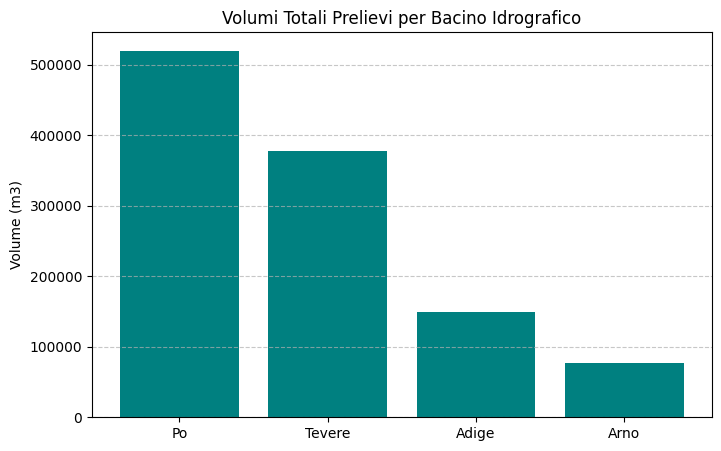

In [13]:
import matplotlib.pyplot as plt

# 1. Eseguiamo la query e salviamo il risultato in un DataFrame
df_risultato_2 = pd.read_sql_query(query_2, engine)

# 2. Ora creiamo il grafico usando la variabile che contiene i DATI
plt.figure(figsize=(8, 5))
plt.bar(df_risultato_2['nome_bacino'], df_risultato_2['volume_totale'], color='teal')

# Personalizzazione
plt.title('Volumi Totali Prelievi per Bacino Idrografico')
plt.ylabel('Volume (m3)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()